# 雪球与 Phoenix：价格和敏感度

使用明确的单标的示范条款：[现金流与接口说明](../docs/ROADMAP.md)。先在项目虚拟环境中运行 `maturin develop --release`，选择该环境的 Python 内核。本例一年 252 个敲入观察步、季度票息/敲出观察。

雪球票息为年化 rate；Phoenix 票息为每观察期现金金额。`reference_spot=100` 在所有情景与 Greeks 中保持固定。Greeks 使用共同随机数，theta 是观察时间同比缩放的 `dV/dT`。

In [1]:
import math
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import fuzzy_enigma as fe

PATHS, SEED = 12_000, 42
engine = fe.McEngine(paths=PATHS, seed=SEED, antithetic=True, parallel=True)
records = []

def timed(label, call, **parameters):
    start = perf_counter()
    result = call()
    record = dict(label=label, price=result.price, std_error=result.std_error,
                  samples=result.samples, ci95=result.confidence_95(),
                  elapsed_s=perf_counter()-start, paths=PATHS, seed=SEED,
                  parameters=parameters)
    records.append(record)
    return result

print('module:', fe.__version__)
print('engine:', engine)

dates = [63, 126, 189, 252]
base = dict(spot=100.0, r=0.03, q=0.0, sigma=0.25, t=1.0, steps=252)
model = fe.GbmModel(**base)
print('base model:', base, 'dates:', dates)

snowball = timed('Snowball baseline', lambda: engine.price_snowball(
    model, 100.0, 100.0, 0.12, 70.0, 103.0, dates), **base, ki=70.0, ko=103.0, coupon_rate=0.12)
for memory in (False, True):
    phoenix = timed(f'Phoenix memory={memory}', lambda: engine.price_phoenix(
        model, 100.0, 100.0, 2.0, 80.0, 60.0, 105.0, dates, dates, memory=memory),
        **base, ki=60.0, ko=105.0, coupon_barrier=80.0, coupon_cash=2.0, memory=memory)
    print('Phoenix', memory, phoenix)
print('Snowball:', snowball)
print('Snowball Greeks:', engine.greeks_snowball(model, 100.0, 100.0, 0.12, 70.0, 103.0, dates))
print('Phoenix Greeks:', engine.greeks_phoenix(model, 100.0, 100.0, 2.0, 80.0, 60.0, 105.0, dates, dates, memory=True))


module: 0.1.0
engine: McEngine(paths=12000, seed=42, antithetic=true, parallel=true)
base model: {'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252} dates: [63, 126, 189, 252]
Phoenix False PriceResult(price=100.936246, std_error=0.074656, samples=6000, ci95=[100.789922, 101.082569])
Phoenix True PriceResult(price=101.117280, std_error=0.075062, samples=6000, ci95=[100.970162, 101.264398])
Snowball: PriceResult(price=100.018688, std_error=0.118195, samples=6000, ci95=[99.787029, 100.250346])
Snowball Greeks: Greeks(delta=0.320789, gamma=0.042604, vega=-62.991796, theta=-4.963951, rho=-41.365915)
Phoenix Greeks: Greeks(delta=0.081582, gamma=-0.071626, vega=-33.720151, theta=-7.386907, rho=-69.552639)


## 敲入障碍和票息

使用同一 seed 比较情景。越高的敲入障碍使更多路径进入到期损失分支；提高雪球票息增加敲出或未敲入路径的支付。误差条表示采样 95% CI。

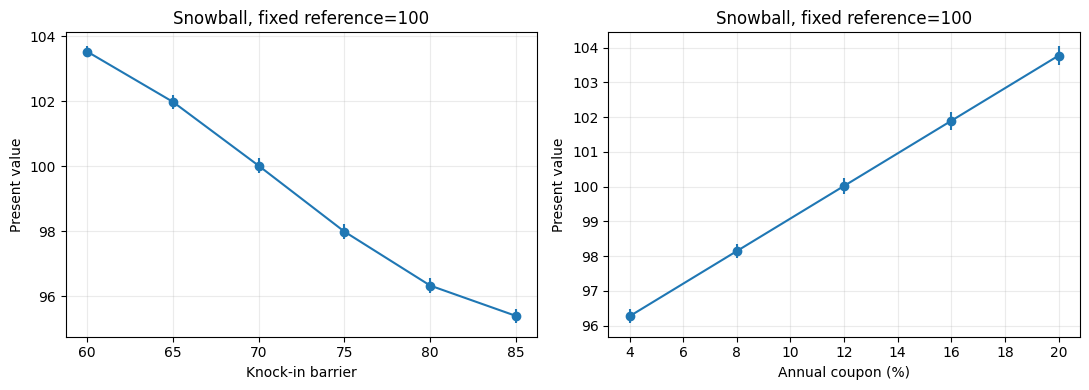

In [2]:
ki_levels = np.linspace(60.0, 85.0, 6)
coupon_rates = np.linspace(0.04, 0.20, 5)
ki_results = [timed('Snowball KI sweep', lambda ki=float(ki): engine.price_snowball(
    model, 100.0, 100.0, 0.12, ki, 103.0, dates), **base, ki=float(ki), ko=103.0, coupon_rate=0.12)
    for ki in ki_levels]
coupon_results = [timed('Snowball coupon sweep', lambda coupon=float(c): engine.price_snowball(
    model, 100.0, 100.0, coupon, 70.0, 103.0, dates), **base, ki=70.0, ko=103.0, coupon_rate=float(c))
    for c in coupon_rates]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xs, rs, xlabel in [(axes[0], ki_levels, ki_results, 'Knock-in barrier'),
                            (axes[1], 100*coupon_rates, coupon_results, 'Annual coupon (%)')]:
    ax.errorbar(xs, [x.price for x in rs], yerr=[1.96*x.std_error for x in rs], fmt='o-')
    ax.set(xlabel=xlabel, ylabel='Present value', title='Snowball, fixed reference=100')
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 波动率情景与 vega

雪球在提前敲出、保息和损失分支之间切换，价格对波动率的敏感度可能不类似普通欧式期权。下图同时展示价格与有限差分 vega；保持合同参考价和障碍不变。

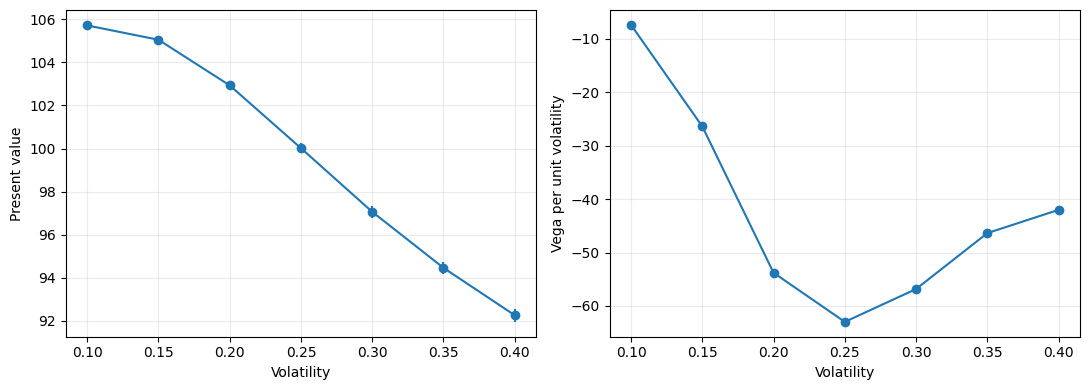

In [3]:
vols = np.linspace(0.10, 0.40, 7)
vol_results, vegas = [], []
for vol in vols:
    params = {**base, 'sigma': float(vol)}
    m = fe.GbmModel(**params)
    vol_results.append(timed('Snowball vol sweep', lambda: engine.price_snowball(
        m, 100.0, 100.0, 0.12, 70.0, 103.0, dates), **params, ki=70.0, ko=103.0, coupon_rate=0.12))
    vegas.append(engine.greeks_snowball(m, 100.0, 100.0, 0.12, 70.0, 103.0, dates).vega)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(vols, [x.price for x in vol_results], yerr=[1.96*x.std_error for x in vol_results], fmt='o-')
axes[0].set(xlabel='Volatility', ylabel='Present value')
axes[1].plot(vols, vegas, 'o-')
axes[1].set(xlabel='Volatility', ylabel='Vega per unit volatility')
for ax in axes: ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


In [4]:
for row in records:
    print(f"{row['label']:<28} price={row['price']:9.5f} SE={row['std_error']:.5f} "
          f"elapsed={row['elapsed_s']:.3f}s paths={row['paths']} seed={row['seed']} "
          f"params={row['parameters']}")


Snowball baseline            price=100.01869 SE=0.11820 elapsed=0.007s paths=12000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'ki': 70.0, 'ko': 103.0, 'coupon_rate': 0.12}
Phoenix memory=False         price=100.93625 SE=0.07466 elapsed=0.006s paths=12000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'ki': 60.0, 'ko': 105.0, 'coupon_barrier': 80.0, 'coupon_cash': 2.0, 'memory': False}
Phoenix memory=True          price=101.11728 SE=0.07506 elapsed=0.006s paths=12000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'ki': 60.0, 'ko': 105.0, 'coupon_barrier': 80.0, 'coupon_cash': 2.0, 'memory': True}
Snowball KI sweep            price=103.53353 SE=0.08459 elapsed=0.006s paths=12000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'ki': 60.0, 'ko': 103.0, 'coupon_rate': 0.12}
Snowball KI sweep            price=101.98